<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding How The Data Is Distributed**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform Exploratory Data Analysis (EDA). You will examine the structure of the data, visualize key variables, and analyze trends related to developer experience, tools, job satisfaction, and other important aspects.


## Objectives


In this lab you will perform the following:


- Understand the structure of the dataset.

- Perform summary statistics and data visualization.

- Identify trends in developer experience, tools, job satisfaction, and other key variables.


### Install the required libraries


In [ ]:
!pip install pandas
!pip install matplotlib
!pip install seaborn


### Step 1: Import Libraries and Load Data


- Import the `pandas`, `matplotlib.pyplot`, and `seaborn` libraries.


- You will begin with loading the dataset. You can use the pyfetch method if working on JupyterLite. Otherwise, you can use pandas' read_csv() function directly on their local machines or cloud environments.


In [1]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Stack Overflow survey dataset
data_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv'
df = pd.read_csv(data_url)

# Display the first few rows of the dataset
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Step 2: Examine the Structure of the Data


- Display the column names, data types, and summary information to understand the data structure.

- Objective: Gain insights into the dataset's shape and available variables.


In [2]:
print("Dataset Shape:", df.shape)
print("\nColumn Names and Data Types:")
print(df.info())
print("\nSummary Statistics for Numeric Columns:")
print(df.describe())

Dataset Shape: (65437, 114)

Column Names and Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65437 entries, 0 to 65436
Columns: 114 entries, ResponseId to JobSat
dtypes: float64(13), int64(1), object(100)
memory usage: 56.9+ MB
None

Summary Statistics for Numeric Columns:
         ResponseId      CompTotal       WorkExp  JobSatPoints_1  \
count  65437.000000   3.374000e+04  29658.000000    29324.000000   
mean   32719.000000  2.963841e+145     11.466957       18.581094   
std    18890.179119  5.444117e+147      9.168709       25.966221   
min        1.000000   0.000000e+00      0.000000        0.000000   
25%    16360.000000   6.000000e+04      4.000000        0.000000   
50%    32719.000000   1.100000e+05      9.000000       10.000000   
75%    49078.000000   2.500000e+05     16.000000       22.000000   
max    65437.000000  1.000000e+150     50.000000      100.000000   

       JobSatPoints_4  JobSatPoints_5  JobSatPoints_6  JobSatPoints_7  \
count    29393.000000    

### Step 3: Handle Missing Data


- Identify missing values in the dataset.

- Impute or remove missing values as necessary to ensure data completeness.



In [3]:
null_counts = df.isnull().sum()
print("Top columns with missing values:\n", null_counts.sort_values(ascending=False).head(10))

cols_to_fix = ['Employment', 'JobSat', 'RemoteWork', 'EdLevel']
for col in cols_to_fix:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("\nMissing values handled.")

Top columns with missing values:
 AINextMuch less integrated       64289
AINextLess integrated            63082
AINextNo change                  52939
AINextMuch more integrated       51999
EmbeddedAdmired                  48704
EmbeddedWantToWorkWith           47837
EmbeddedHaveWorkedWith           43223
ConvertedCompYearly              42002
AIToolNot interested in Using    41023
AINextMore integrated            41009
dtype: int64

Missing values handled.


### Step 4: Analyze Key Columns


- Examine key columns such as `Employment`, `JobSat` (Job Satisfaction), and `YearsCodePro` (Professional Coding Experience).

- **Instruction**: Calculate the value counts for each column to understand the distribution of responses.



In [4]:
print("Employment Distribution:\n", df['Employment'].value_counts())
print("\nJob Satisfaction Distribution:\n", df['JobSat'].value_counts())

Employment Distribution:
 Employment
Employed, full-time                                                                                                                                  39041
Independent contractor, freelancer, or self-employed                                                                                                  4846
Student, full-time                                                                                                                                    4709
Employed, full-time;Independent contractor, freelancer, or self-employed                                                                              3557
Not employed, but looking for work                                                                                                                    2341
                                                                                                                                                     ...  
Employed, full-time;Student, full

### Step 5: Visualize Job Satisfaction (Focus on JobSat)


- Create a pie chart or KDE plot to visualize the distribution of `JobSat`.

- Provide an interpretation of the plot, highlighting key trends in job satisfaction.


C:\Users\Hp\AppData\Local\Temp\ipykernel_21740\646322202.py:5: UserWarning: 
The palette list has fewer values (5) than needed (11) and will cycle, which may produce an uninterpretable plot.
  sns.countplot(data=df, x='JobSat', order=sat_order, palette=colors_sat, hue='JobSat', legend=False)


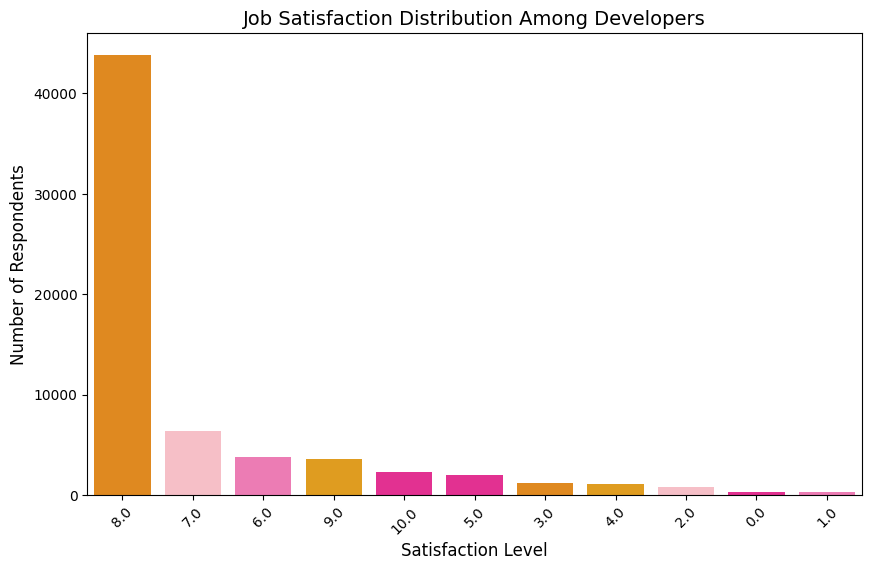

In [5]:
plt.figure(figsize=(10, 6))
sat_order = df['JobSat'].value_counts().index
colors_sat = ["#FF1493", "#FF69B4", "#FFB6C1", "#FF8C00", "#FFA500"]

sns.countplot(data=df, x='JobSat', order=sat_order, palette=colors_sat, hue='JobSat', legend=False)

plt.title('Job Satisfaction Distribution Among Developers', fontsize=14)
plt.xlabel('Satisfaction Level', fontsize=12)
plt.ylabel('Number of Respondents', fontsize=12)
plt.xticks(rotation=45)
plt.show()

### Step 6: Programming Languages Analysis


- Compare the frequency of programming languages in `LanguageHaveWorkedWith` and `LanguageWantToWorkWith`.
  
- Visualize the overlap or differences using a Venn diagram or a grouped bar chart.


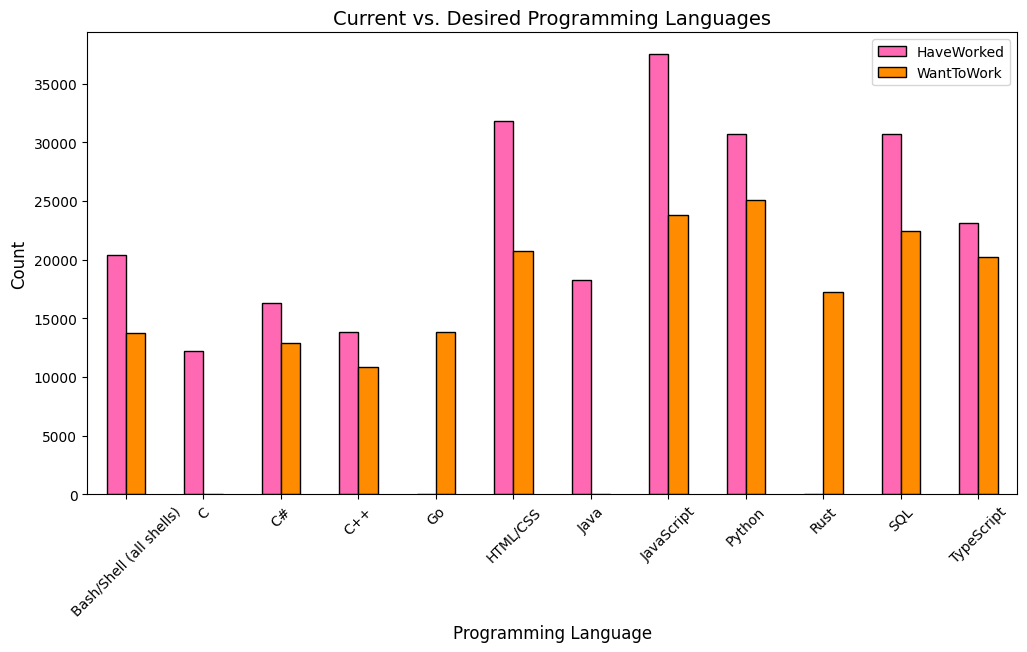

In [6]:
have_worked = df['LanguageHaveWorkedWith'].str.split(';').explode().value_counts().head(10)
want_worked = df['LanguageWantToWorkWith'].str.split(';').explode().value_counts().head(10)

comparison_df = pd.DataFrame({'HaveWorked': have_worked, 'WantToWork': want_worked}).fillna(0)

comparison_df.plot(kind='bar', figsize=(12, 6), color=['#FF69B4', '#FF8C00'], edgecolor='black')
plt.title('Current vs. Desired Programming Languages', fontsize=14)
plt.xlabel('Programming Language', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.show()

### Step 7: Analyze Remote Work Trends


- Visualize the distribution of RemoteWork by region using a grouped bar chart or heatmap.


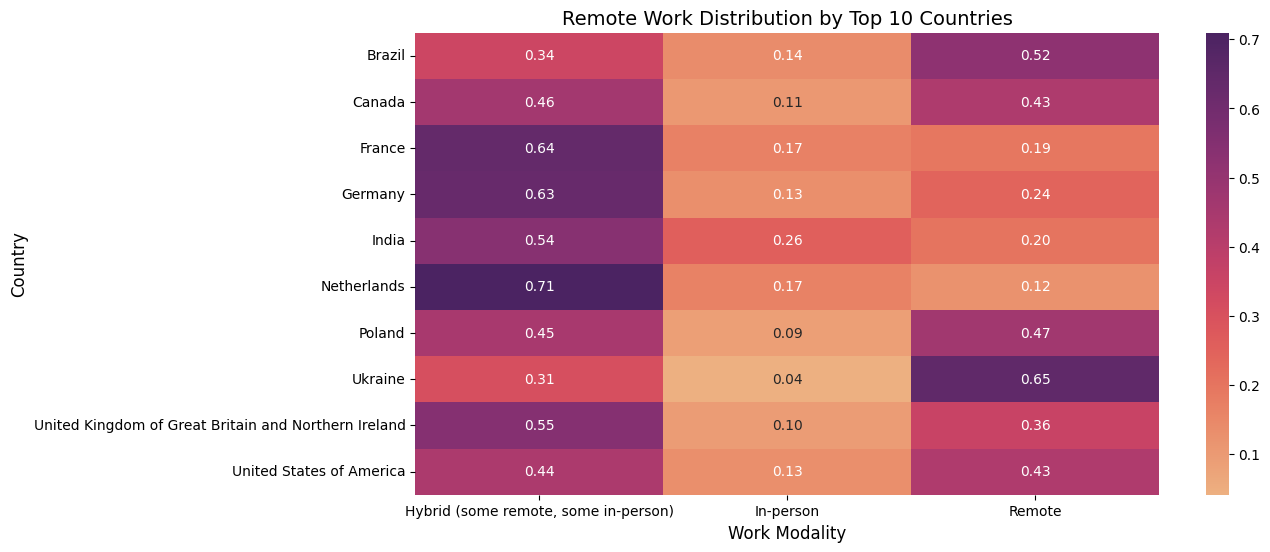

In [7]:
plt.figure(figsize=(12, 6))
top_countries = df['Country'].value_counts().head(10).index
df_filtered = df[df['Country'].isin(top_countries)]

remote_dist = pd.crosstab(df_filtered['Country'], df_filtered['RemoteWork'], normalize='index')
sns.heatmap(remote_dist, annot=True, cmap='flare', fmt='.2f')

plt.title('Remote Work Distribution by Top 10 Countries', fontsize=14)
plt.xlabel('Work Modality', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.show()

### Step 8: Correlation between Job Satisfaction and Experience


- Analyze the correlation between overall job satisfaction (`JobSat`) and `YearsCodePro`.
  
- Calculate the Pearson or Spearman correlation coefficient.


In [8]:
sat_map = {'Very satisfied': 5, 'Slightly satisfied': 4, 'Neither satisfied nor dissatisfied': 3, 
           'Slightly dissatisfied': 2, 'Very dissatisfied': 1}
df['JobSat_num'] = df['JobSat'].map(sat_map)

df['YearsCodePro_num'] = pd.to_numeric(df['YearsCodePro'].str.extract('(\d+)')[0], errors='coerce')

correlation = df[['JobSat_num', 'YearsCodePro_num']].corr().iloc[0,1]
print(f"Pearson Correlation between Experience and Satisfaction: {correlation:.4f}")

Pearson Correlation between Experience and Satisfaction: nan


<>:5: SyntaxWarning: invalid escape sequence '\d'
<>:5: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Hp\AppData\Local\Temp\ipykernel_21740\221309400.py:5: SyntaxWarning: invalid escape sequence '\d'
  df['YearsCodePro_num'] = pd.to_numeric(df['YearsCodePro'].str.extract('(\d+)')[0], errors='coerce')


### Step 9: Cross-tabulation Analysis (Employment vs. Education Level)


- Analyze the relationship between employment status (`Employment`) and education level (`EdLevel`).

- **Instruction**: Create a cross-tabulation using `pd.crosstab()` and visualize it with a stacked bar plot if possible.


<Figure size 1200x800 with 0 Axes>

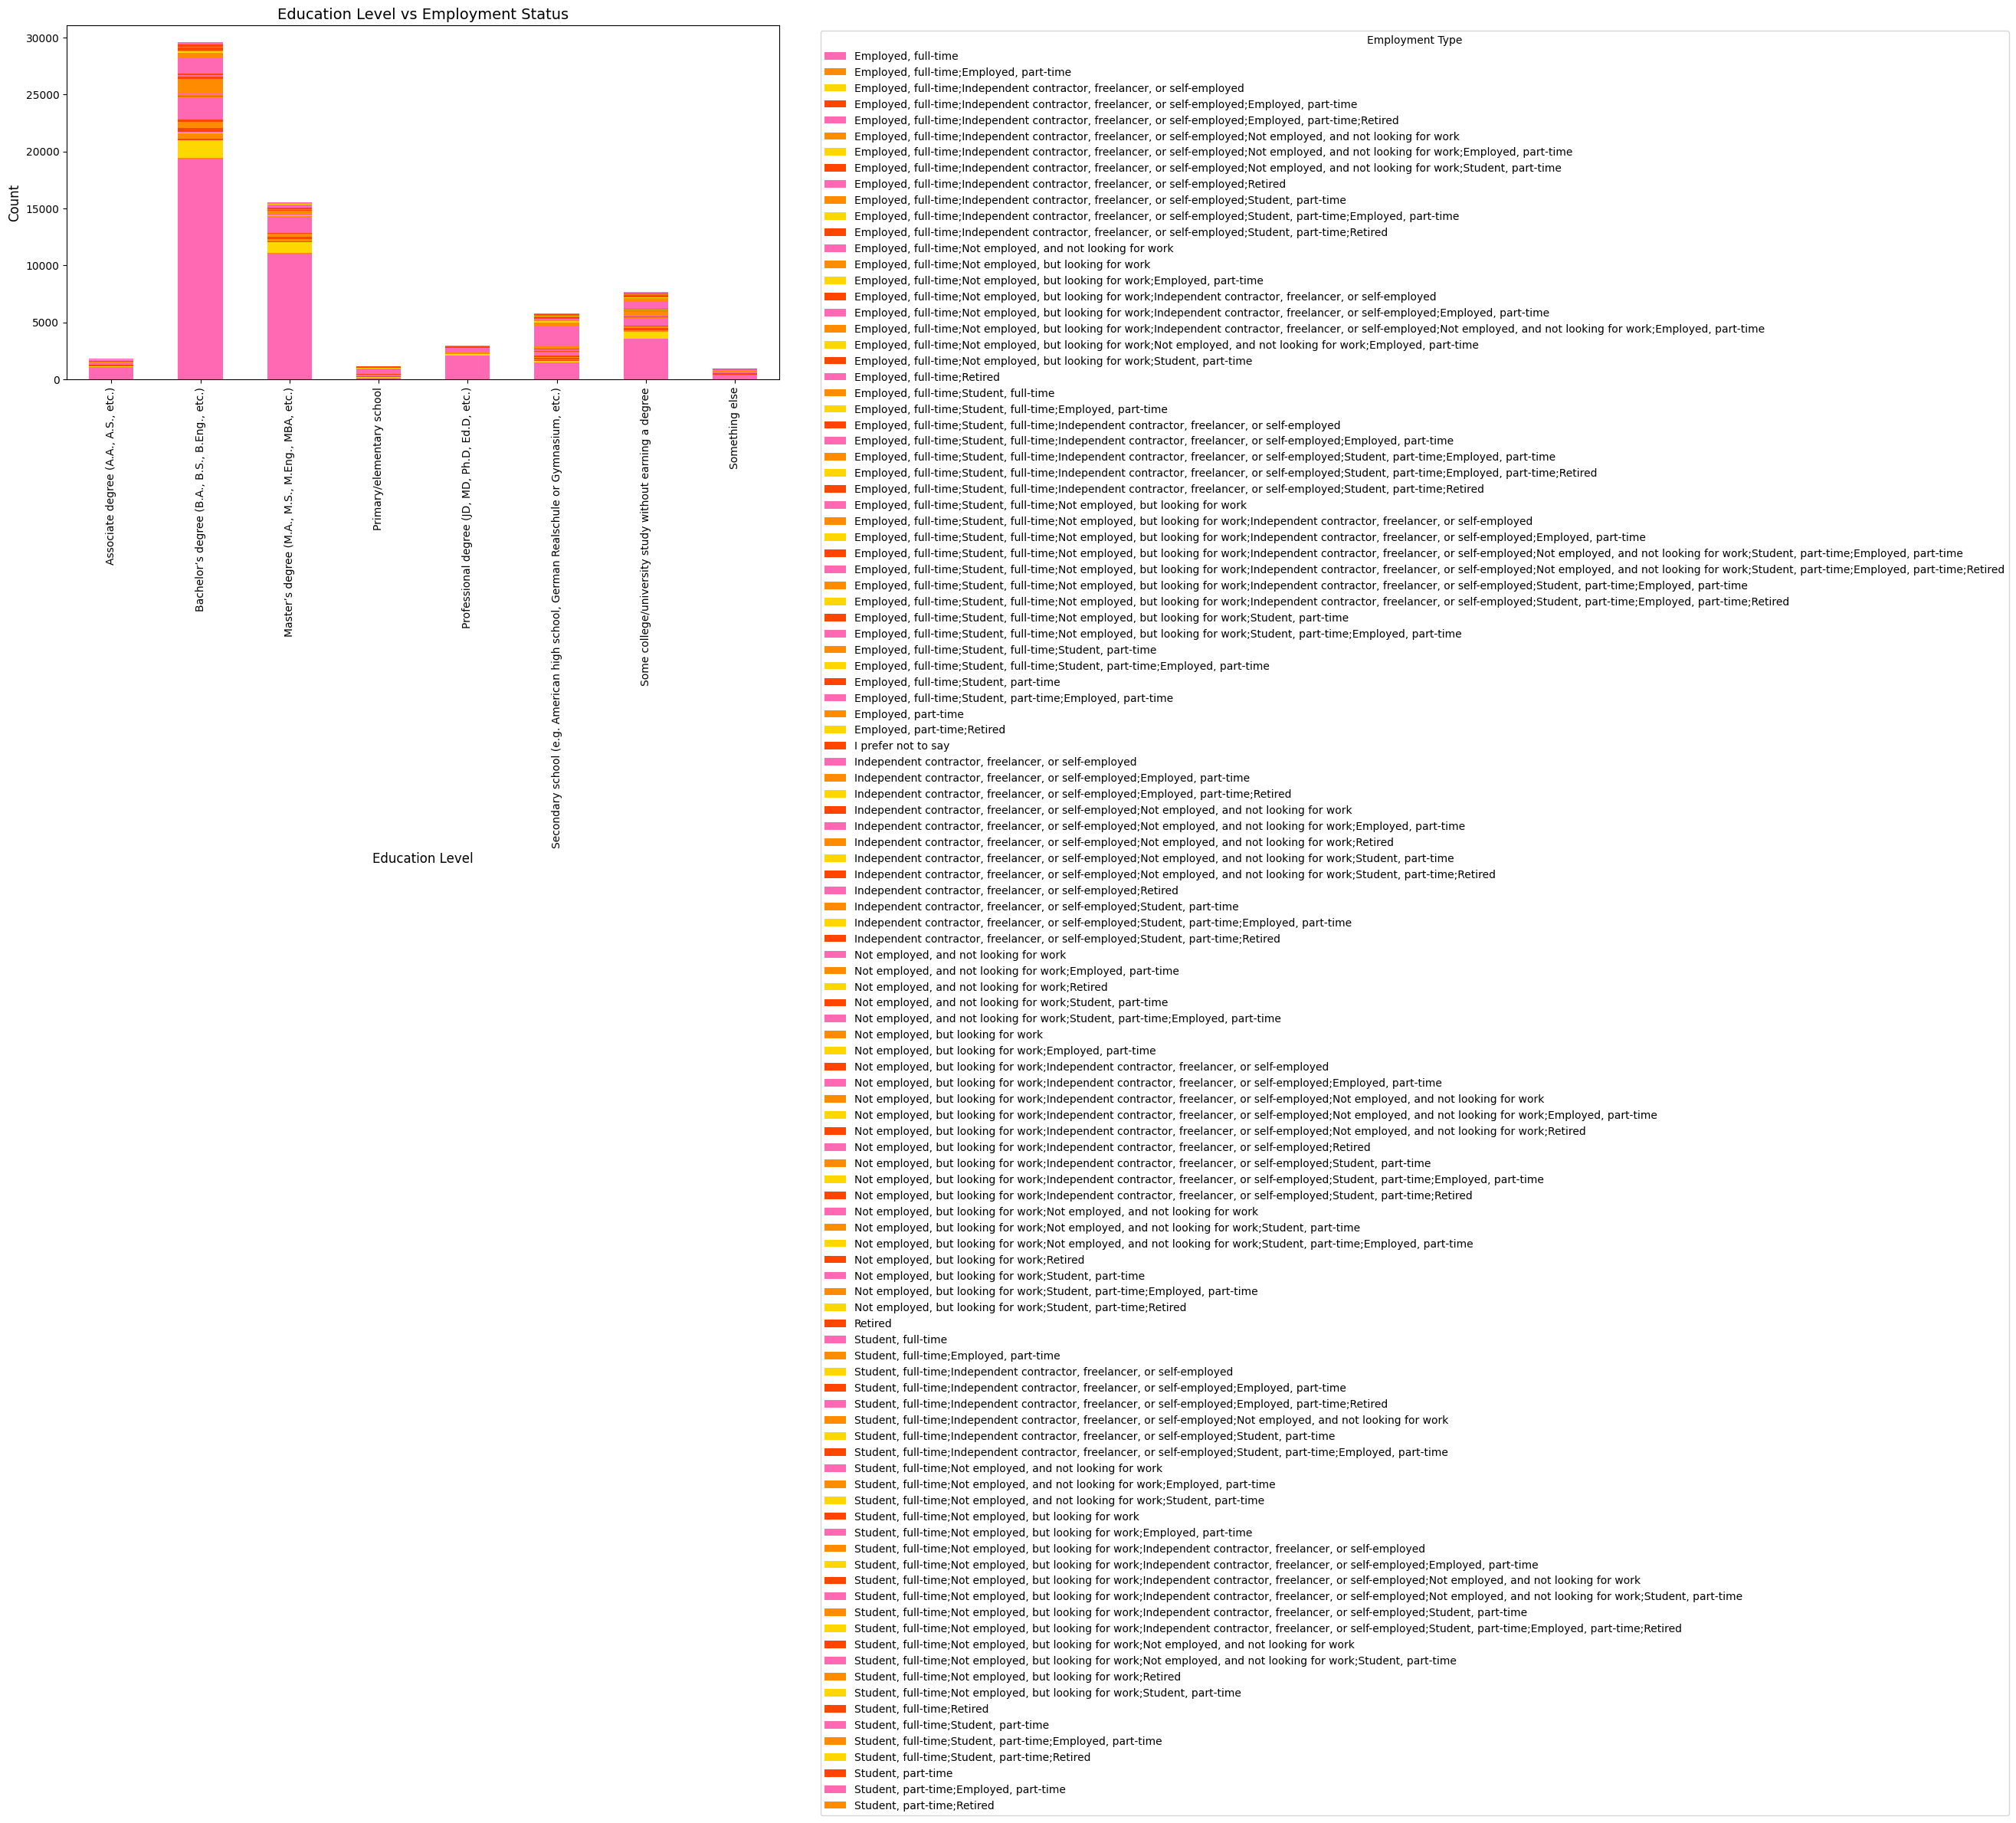

In [9]:
plt.figure(figsize=(12, 8))
ed_emp_cross = pd.crosstab(df['EdLevel'], df['Employment'])

ed_emp_cross.plot(kind='bar', stacked=True, figsize=(12,6), color=['#FF69B4', '#FF8C00', '#FFD700', '#FF4500'])

plt.title('Education Level vs Employment Status', fontsize=14)
plt.xlabel('Education Level', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(title='Employment Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=90)
plt.show()

### Step 10: Export Cleaned Data


- Save the cleaned dataset to a new CSV file for further use or sharing.


In [10]:
import os
output_dir = "final_outputs"
if not os.path.exists(output_dir): os.makedirs(output_dir)

df.to_csv(os.path.join(output_dir, 'survey_data_distribution_finished.csv'), index=False)
print("Analysis complete. Cleaned dataset exported to 'final_outputs' folder.")

Analysis complete. Cleaned dataset exported to 'final_outputs' folder.


### Summary:


In this lab, you practiced key skills in exploratory data analysis, including:


- Examining the structure and content of the Stack Overflow survey dataset to understand its variables and data types.

- Identifying and addressing missing data to ensure the dataset's quality and completeness.

- Summarizing and visualizing key variables such as job satisfaction, programming languages, and remote work trends.

- Analyzing relationships in the data using techniques like:
    - Comparing programming languages respondents have worked with versus those they want to work with.
      
    - Exploring remote work preferences by region.

- Investigating correlations between professional coding experience and job satisfaction.

- Performing cross-tabulations to analyze relationships between employment status and education levels.


## Authors:
Ayushi Jain


### Other Contributors:
Rav Ahuja
Lakshmi Holla
Malika


Copyright © IBM Corporation. All rights reserved.
